# ML Project - Predicting Students Marks based upon the number of Studing Hours

In [54]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Akash\Desktop\FSDS\ML\Predicting_student_marks_Project\student_study_hours_marks_dataset.csv")

In [5]:
df

,Studying Hours,Marks Obtained
0,0.3,26.3
1,6.8,79.6
2,0.9,29.7
3,5.1,62.6
4,NaN,34.9
...,...,...
195,4.8,74.0
196,7.3,75.8
197,0.9,47.0
198,2.4,31.6


In [6]:
df.head(4)

,Studying Hours,Marks Obtained
0,0.3,26.3
1,6.8,79.6
2,0.9,29.7
3,5.1,62.6


In [7]:
df.tail(4)

,Studying Hours,Marks Obtained
196,7.3,75.8
197,0.9,47.0
198,2.4,31.6
199,0.3,29.6


In [9]:
df.isnull().any()

Studying Hours     True
Marks Obtained    False
dtype: bool

In [10]:
df.isnull().sum()

Studying Hours    10
Marks Obtained     0
dtype: int64

# Descriptive Data ANalysis

In [11]:
df.info

<bound method DataFrame.info of      Studying Hours  Marks Obtained
0               0.3            26.3
1               6.8            79.6
2               0.9            29.7
3               5.1            62.6
4               NaN            34.9
..              ...             ...
195             4.8            74.0
196             7.3            75.8
197             0.9            47.0
198             2.4            31.6
199             0.3            29.6

[200 rows x 2 columns]>

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Studying Hours  190 non-null    float64
 1   Marks Obtained  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [13]:
df.describe()

,Studying Hours,Marks Obtained
count,190.000000,200.00000
mean,4.849474,59.88750
std,2.846250,21.72241
min,0.100000,10.50000
25%,2.600000,43.50000
50%,5.100000,62.30000
75%,7.150000,76.32500
max,10.000000,100.00000


# Handling the missing values

In [14]:
df.columns

Index(['Studying Hours', 'Marks Obtained'], dtype='object')

In [22]:
df["Studying Hours"].mean()

np.float64(4.849473684210526)

In [77]:
df.mean()

Studying Hours     4.8495
Marks Obtained    59.8875
dtype: float64

In [103]:
avg_hours = round(df["Studying Hours"].mean(), 2)
print(avg_hours)

4.85


In [104]:
df["Studying Hours"] = df["Studying Hours"].fillna(avg_hours)

# OR you can use --->  df["Studying Hours"].fillna(avg_hours, inplace = True)

In [105]:
df.isnull().any()

Studying Hours    False
Marks Obtained    False
dtype: bool

# Slipliting the data into Independant and Dependant variable

In [106]:
x = df.drop('Marks Obtained', axis = 1)

In [107]:
y = df.drop("Studying Hours", axis = 1)

In [108]:
x

,Studying Hours
0,0.30
1,6.80
2,0.90
3,5.10
4,4.85
...,...
195,4.80
196,7.30
197,0.90
198,2.40


In [109]:
y

,Marks Obtained
0,26.3
1,79.6
2,29.7
3,62.6
4,34.9
...,...
195,74.0
196,75.8
197,47.0
198,31.6


In [110]:
x.isna().sum()

Studying Hours    0
dtype: int64

In [111]:
y.isna().sum()

Marks Obtained    0
dtype: int64

# Spliting the data into Train and Test

In [112]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state=0)

In [113]:
x_train.shape

(160, 1)

In [114]:
y_train.shape

(160, 1)

In [115]:
x_test.shape

(40, 1)

In [116]:
y_test.shape

(40, 1)

# Select the Model and Train it

In [117]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [118]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
lr.coef_      # value of M

array([[6.99393844]])

In [120]:
lr.intercept_      # value of C

array([26.23170153])

In [121]:
m = 6.99
c = 26.23

y = m * 10 + c  
y

96.13000000000001

In [122]:
m = 6.99
c = 26.23

y = m * 10.5 + c  
y

99.625

In [123]:
lr.predict([[9]]).round(2)

C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[89.18]])

# Now Predicting the y_test values

In [124]:
y_pred = lr.predict(x_test)

In [125]:
y_pred

array([[68.894726  ],
       [60.15230295],
       [91.27532899],
       [44.41594147],
       [80.78442134],
       [68.894726  ],
       [63.99896909],
       [93.37351052],
       [69.59411984],
       [77.98684596],
       [33.22563997],
       [76.58805828],
       [73.09108906],
       [62.6001814 ],
       [69.59411984],
       [75.18927059],
       [86.37957209],
       [47.21351684],
       [44.41594147],
       [66.79654446],
       [93.37351052],
       [80.08502749],
       [60.50199987],
       [63.99896909],
       [59.10321218],
       [66.79654446],
       [60.15230295],
       [54.20745528],
       [61.90078756],
       [30.4280646 ],
       [51.4098799 ],
       [31.12745844],
       [68.894726  ],
       [45.11533531],
       [28.32988306],
       [50.71048606],
       [54.90684912],
       [60.15230295],
       [54.20745528],
       [69.59411984]])

In [126]:
# Comparing predictions (y_pred) with Actual Values (y_test)

In [127]:
pd.DataFrame(np.c_[x_test,y_test,y_pred], columns = ['Study Hours', 'Student Original Marks', 'Students Predicted Marks'])

,Study Hours,Student Original Marks,Students Predicted Marks
0,6.10,87.6,68.894726
1,4.85,68.2,60.152303
2,9.30,100.0,91.275329
3,2.60,44.0,44.415941
4,7.80,73.4,80.784421
5,6.10,68.9,68.894726
6,5.40,65.9,63.998969
7,9.60,99.3,93.373511
8,6.20,76.6,69.594120
9,7.40,69.5,77.986846


# Fine Tune Model

In [129]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [133]:
lr.score(x_test,y_test)  # Variance

0.7019157736438626

In [134]:
lr.score(x_train,y_train)  # Bias

0.8313649903752144

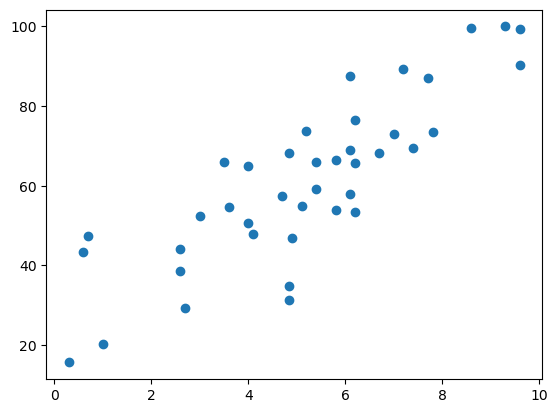

In [135]:
plt.scatter(x_test, y_test)

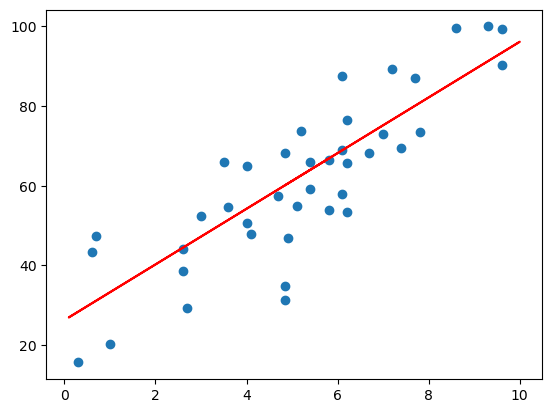

In [138]:
plt.scatter(x_test, y_test)
plt.plot(x_train, lr.predict(x_train), color='red')

# Now Saving the lr Model

In [139]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [148]:
import joblib
joblib.dump(lr, 'Predicting_students_marks.pickle')

['Predicting_students_marks.pickle']

In [149]:
pwd

'C:\\Users\\Akash'

In [150]:
model = joblib.load('Predicting_students_marks.pickle')

In [151]:
pwd

'C:\\Users\\Akash'